In [ ]:
#Week 4 -2
#Bolortulga Seded
#24045487
#Imbalanced Data 

In [2]:

import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from collections import Counter
from itertools import chain

plt.style.use('ggplot')
np.random.seed(37)

X, y = make_classification(**{
    'n_samples': 5000,
    'n_features': 5,
    'n_classes': 2,
    'random_state': 37
})

columns = [f'x{i}' for i in range(X.shape[1])] + ['y']
df = pd.DataFrame(np.hstack([X, y.reshape(-1, 1)]), columns=columns)
print(df.shape)
df.head()

(5000, 6)


,x0,x1,x2,x3,x4,y
0,-0.729402,0.390517,-0.603771,0.286312,-0.266412,0.0
1,0.030495,-0.970299,1.223902,-0.343972,-0.479884,0.0
2,-0.657696,-0.811643,-1.075159,0.405169,-0.022806,0.0
3,0.138540,2.012018,-1.825350,0.482964,0.845321,1.0
4,2.231350,-0.705512,-0.453736,-0.238611,1.757486,1.0


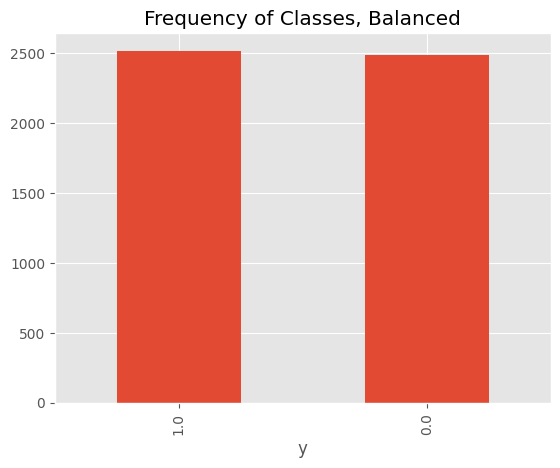

In [3]:
ax = df.y.value_counts().plot(kind='bar')
_ = ax.set_title('Frequency of Classes, Balanced')

(2508, 6)


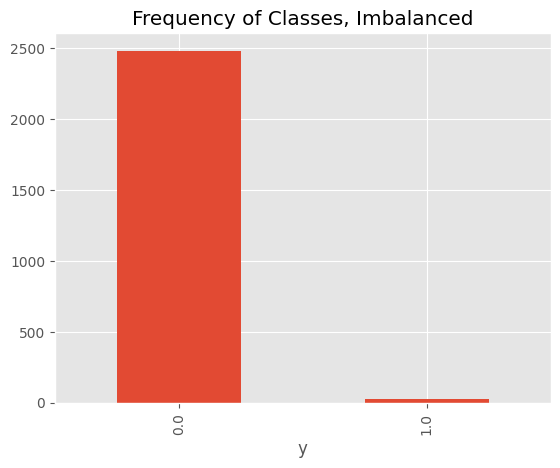

In [3]:

df0 = df[df.y == 0].copy(deep=True).reset_index(drop=True)
df1 = df[df.y == 1].sample(frac=0.01).copy(deep=True).reset_index(drop=True)
df = pd.concat([df0, df1])
print(df.shape)

ax = df.y.value_counts().plot(kind='bar')
_ = ax.set_title('Frequency of Classes, Imbalanced')

In [4]:

X = df[[c for c in df.columns if c != 'y']]
y = df.y

X_orig = pd.DataFrame(X)
y_orig = pd.Series(y)

print(X.shape, y.shape)

(2508, 5) (2508,)


In [5]:

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=37)

rdf = []
for fold, (tr, te) in enumerate(skf.split(X_orig, y_orig)):
    X_tr, X_te = X_orig.iloc[tr], X_orig.iloc[te]
    y_tr, y_te = y_orig.iloc[tr], y_orig.iloc[te]
    model = RandomForestClassifier(n_jobs=-1, random_state=37)
    model.fit(X_tr, y_tr)
    y_pr = model.predict_proba(X_te)[:,1]
    auc = roc_auc_score(y_te, y_pr)
    aps = average_precision_score(y_te, y_pr)
    rdf.append({'auc': auc, 'aps': aps})

rdf = pd.DataFrame(rdf)
rdf[['auc', 'aps']].agg(['mean', 'std'])

,auc,aps
mean,0.972218,0.750400
std,0.080609,0.305972


In [9]:

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN, BorderlineSMOTE, SVMSMOTE, KMeansSMOTE

def get_oversampler(sampler):
    if sampler == 'adasyn':
        return ADASYN(random_state=37, n_neighbors=5)
    elif sampler == 'borderlinesmote':
        return BorderlineSMOTE(random_state=37, k_neighbors=5, m_neighbors=10)  # removed n_jobs
    elif sampler == 'svmsmote':
        return SVMSMOTE(random_state=37, k_neighbors=5, m_neighbors=10)  # removed n_jobs
    elif sampler == 'random':
        return RandomOverSampler(random_state=37)
    else:
        return SMOTE(random_state=37, k_neighbors=5)

def get_results(sampler, f):
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=37)
    results = []
    for fold, (tr, te) in enumerate(skf.split(X_orig, y_orig)):
        X_tr, X_te = X_orig.iloc[tr], X_orig.iloc[te]
        y_tr, y_te = y_orig.iloc[tr], y_orig.iloc[te]
        if sampler != 'none':
            sampling_approach = f(sampler)
            X_tr, y_tr = sampling_approach.fit_resample(X_tr, y_tr)
        model = RandomForestClassifier(n_jobs=-1, random_state=37)
        model.fit(X_tr, y_tr)
        y_pr = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, y_pr)
        aps = average_precision_score(y_te, y_pr)
        results.append({'sampler': sampler, 'auc': auc, 'aps': aps})
    return results

samplers = ['none', 'random', 'smote', 'adasyn', 'borderlinesmote', 'svmsmote']
odf = pd.DataFrame(list(chain(*[get_results(s, get_oversampler) for s in samplers])))
print(odf[['sampler', 'auc', 'aps']].groupby('sampler').agg(['mean', 'std']))

                      auc                 aps          
                     mean       std      mean       std
sampler                                                
adasyn           0.971713  0.080083  0.748178  0.222613
borderlinesmote  0.971511  0.080007  0.734289  0.206186
none             0.972218  0.080609  0.750400  0.305972
random           0.972351  0.079962  0.778178  0.242363
smote            0.972014  0.079815  0.759844  0.204722
svmsmote         0.971881  0.080504  0.739844  0.278877


In [8]:

from imblearn.under_sampling import RandomUnderSampler, NearMiss, EditedNearestNeighbours, RepeatedEditedNearestNeighbours, CondensedNearestNeighbour, OneSidedSelection, NeighbourhoodCleaningRule

def get_undersampler(sampler):
    if sampler == 'random':
        return RandomUnderSampler(random_state=37)
    elif sampler == 'nearmiss1':
        return NearMiss(version=1, n_jobs=-1)
    elif sampler == 'nearmiss2':
        return NearMiss(version=2, n_jobs=-1)
    elif sampler == 'nearmiss3':
        return NearMiss(version=3, n_jobs=-1)
    elif sampler == 'editednn':
        return EditedNearestNeighbours(n_jobs=-1)
    elif sampler == 'reditednn':
        return RepeatedEditedNearestNeighbours(n_jobs=-1)
    elif sampler == 'condensednn':
        return CondensedNearestNeighbour(random_state=37, n_jobs=-1)
    elif sampler == 'onesided':
        return OneSidedSelection(random_state=37, n_jobs=-1)
    elif sampler == 'neighcleanrule':
        return NeighbourhoodCleaningRule(n_jobs=-1)

samplers = ['random', 'nearmiss1', 'nearmiss2', 'nearmiss3',
            'editednn', 'reditednn', 'condensednn', 'onesided', 'neighcleanrule']
udf = pd.DataFrame(list(chain(*[get_results(s, get_undersampler) for s in samplers])))
print(udf[['sampler', 'auc', 'aps']].groupby('sampler').agg(['mean', 'std']))

                     auc                 aps          
                    mean       std      mean       std
sampler                                               
condensednn     0.994261  0.010101  0.746438  0.278687
editednn        0.971847  0.081873  0.745956  0.281920
nearmiss1       0.991982  0.007731  0.661993  0.202126
nearmiss2       0.992929  0.009534  0.678327  0.251700
nearmiss3       0.991876  0.015964  0.727037  0.274334
neighcleanrule  0.972586  0.081067  0.794844  0.270572
onesided        0.971445  0.082091  0.714289  0.278155
random          0.996172  0.006600  0.792222  0.225959
reditednn       0.972047  0.081932  0.767622  0.258529
